In [1]:
import sys
sys.path.append("../src")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from data_loader import load_brent_prices, load_events
from eda_utils import (
    compute_log_returns, run_adf_test, compute_rolling_volatility,
    plot_price_series, plot_log_returns, plot_rolling_volatility, plot_events_overlay
)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (14, 6)

df = load_brent_prices("../data/BrentOilPrices.csv")
events_df = load_events("../data/events.csv")

print("Shape:", df.shape)
print("Date range:", df["Date"].min(), "to", df["Date"].max())
df.head()

Shape: (9011, 2)
Date range: 1987-05-20 00:00:00 to 2022-11-14 00:00:00


,Date,Price
0,1987-05-20,18.63
1,1987-05-21,18.45
2,1987-05-22,18.55
3,1987-05-25,18.60
4,1987-05-26,18.63


In [4]:
# Replace the original Date column with the fully-parsed version
df["Date"] = df["Date_parsed"]
df = df.drop(columns=["Date_parsed"])

df = df.sort_values("Date").reset_index(drop=True)

print("Shape:", df.shape)
print("Date range:", df["Date"].min(), "to", df["Date"].max())
print("Any duplicate dates?", df["Date"].duplicated().sum())
print("Any missing prices?", df["Price"].isna().sum())
df.head()

Shape: (9011, 2)
Date range: 1987-05-20 00:00:00 to 2022-11-14 00:00:00
Any duplicate dates? 0
Any missing prices? 0


,Date,Price
0,1987-05-20,18.63
1,1987-05-21,18.45
2,1987-05-22,18.55
3,1987-05-25,18.60
4,1987-05-26,18.63


In [5]:
# Inspect the tail of the dataset and rows beyond the doc's stated end date (2022-09-30)
print(df.tail(10))
print()
extra_rows = df[df["Date"] > "2022-09-30"]
print("Rows beyond stated end date (2022-09-30):", len(extra_rows))
print(extra_rows)

           Date  Price
9001 2022-11-01  95.12
9002 2022-11-02  96.07
9003 2022-11-03  95.29
9004 2022-11-04  99.53
9005 2022-11-07  99.87
9006 2022-11-08  96.85
9007 2022-11-09  93.05
9008 2022-11-10  94.25
9009 2022-11-11  96.37
9010 2022-11-14  93.59

Rows beyond stated end date (2022-09-30): 31
           Date  Price
8980 2022-10-03  90.68
8981 2022-10-04  93.74
8982 2022-10-05  94.35
8983 2022-10-06  95.65
8984 2022-10-07  98.88
8985 2022-10-10  97.13
8986 2022-10-11  95.17
8987 2022-10-12  93.44
8988 2022-10-13  95.16
8989 2022-10-14  92.22
8990 2022-10-17  91.04
8991 2022-10-18  89.46
8992 2022-10-19  91.34
8993 2022-10-20  91.52
8994 2022-10-21  91.82
8995 2022-10-24  91.57
8996 2022-10-25  91.76
8997 2022-10-26  92.93
8998 2022-10-27  94.17
8999 2022-10-28  94.64
9000 2022-10-31  93.30
9001 2022-11-01  95.12
9002 2022-11-02  96.07
9003 2022-11-03  95.29
9004 2022-11-04  99.53
9005 2022-11-07  99.87
9006 2022-11-08  96.85
9007 2022-11-09  93.05
9008 2022-11-10  94.25
9009 2022-1

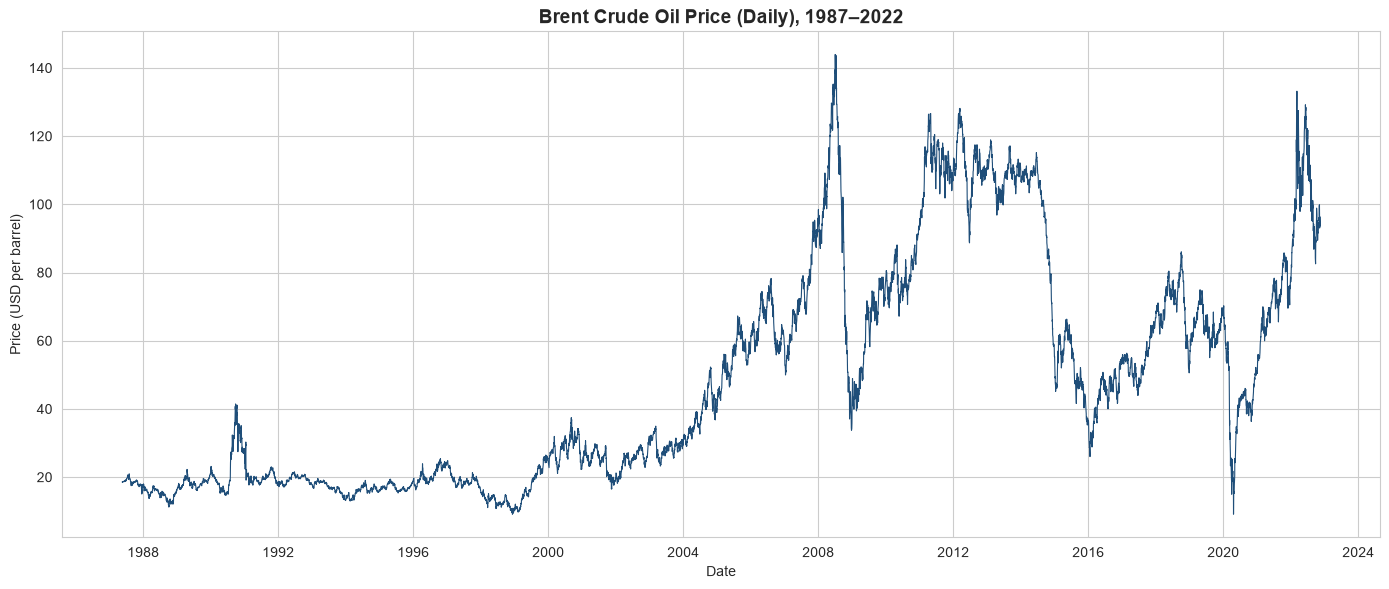

In [6]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(df["Date"], df["Price"], linewidth=0.8, color="#1f4e79")
ax.set_title("Brent Crude Oil Price (Daily), 1987–2022", fontsize=14, fontweight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("Price (USD per barrel)")
plt.tight_layout()
plt.savefig("../notebooks/plot_raw_price_series.png", dpi=150)
plt.show()

count    9010.000000
mean        0.000179
std         0.025532
min        -0.643699
25%        -0.011154
50%         0.000402
75%         0.012127
max         0.412023
Name: Log_Return, dtype: float64


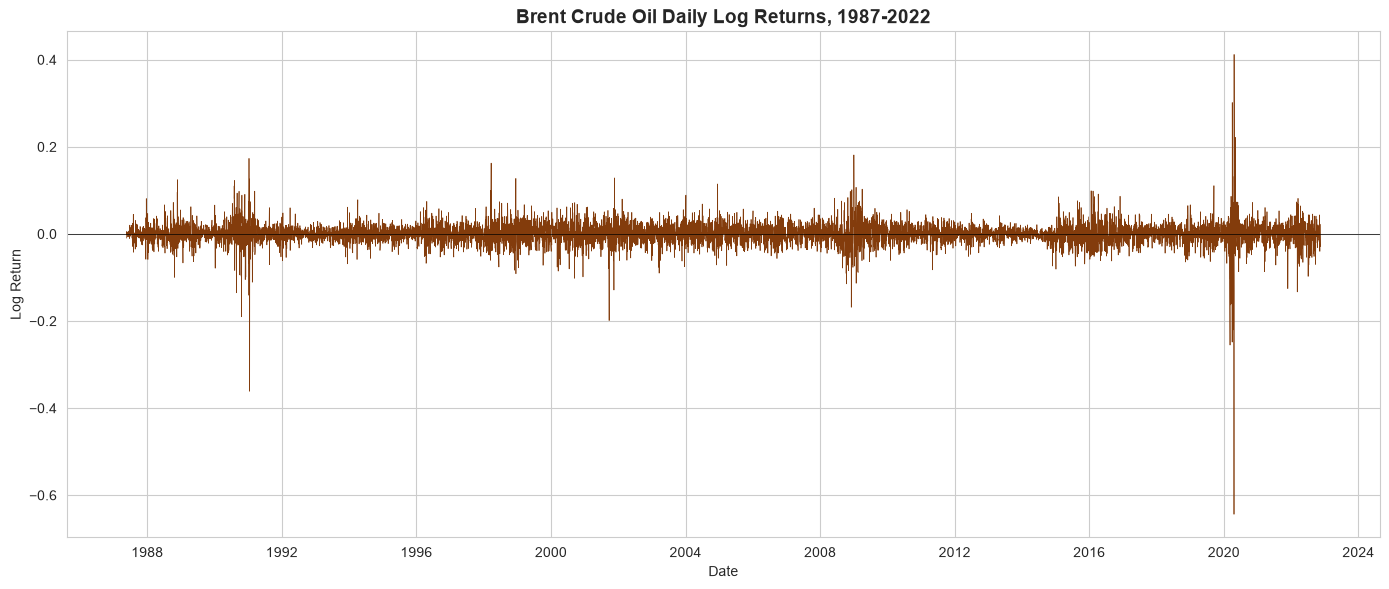

In [2]:
df_clean = compute_log_returns(df)
print(df_clean["Log_Return"].describe())
plot_log_returns(df_clean, save_path="../notebooks/plot_log_returns.png")

In [8]:
# Investigate the most extreme log return days
print("Top 5 largest single-day drops:")
print(df_clean.nsmallest(5, "Log_Return")[["Date", "Price", "Log_Return"]])
print()
print("Top 5 largest single-day jumps:")
print(df_clean.nlargest(5, "Log_Return")[["Date", "Price", "Log_Return"]])

Top 5 largest single-day drops:
           Date  Price  Log_Return
8358 2020-04-21   9.12   -0.643699
935  1991-01-17  21.10   -0.361214
8329 2020-03-09  35.33   -0.255175
8346 2020-04-01  14.97   -0.248341
8352 2020-04-09  20.23   -0.220471

Top 5 largest single-day jumps:
           Date  Price  Log_Return
8359 2020-04-22  13.77    0.412023
8347 2020-04-02  20.24    0.301613
8368 2020-05-05  25.46    0.221574
8348 2020-04-03  24.33    0.184049
5498 2009-01-02  42.94    0.181297


In [3]:
adf_price = run_adf_test(df["Price"], label="Raw Price")
adf_returns = run_adf_test(df_clean["Log_Return"], label="Log Returns")

for result in [adf_price, adf_returns]:
    print(f"=== ADF Test: {result['label']} ===")
    print(f"ADF Statistic: {result['adf_statistic']:.4f}")
    print(f"p-value: {result['p_value']:.4f}")
    print(f"Critical Values: {result['critical_values']}")
    print("Stationary?", "Yes" if result["is_stationary"] else "No (fails to reject unit root)")
    print()

=== ADF Test: Raw Price ===
ADF Statistic: -1.9939
p-value: 0.2893
Critical Values: {'1%': np.float64(-3.4310783342658615), '5%': np.float64(-2.861861876398633), '10%': np.float64(-2.566941329781918)}
Stationary? No (fails to reject unit root)

=== ADF Test: Log Returns ===
ADF Statistic: -16.4271
p-value: 0.0000
Critical Values: {'1%': np.float64(-3.4310783342658615), '5%': np.float64(-2.861861876398633), '10%': np.float64(-2.566941329781918)}
Stationary? Yes



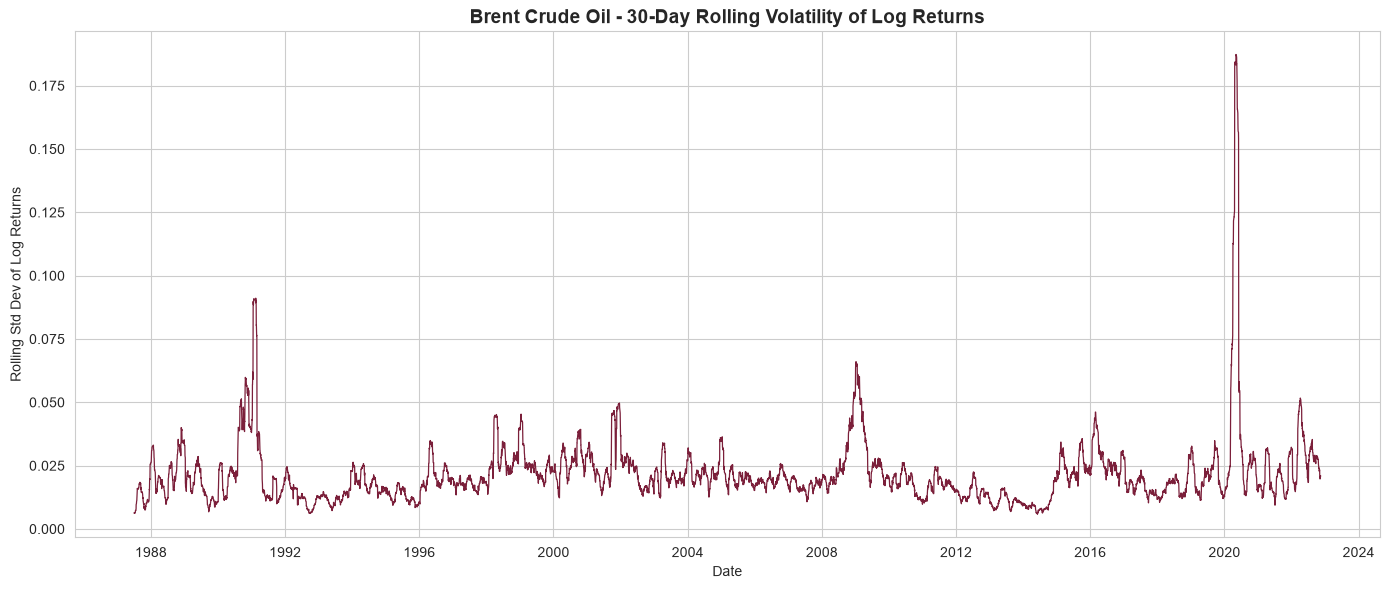

In [4]:
df_clean = compute_rolling_volatility(df_clean, window=30)
plot_rolling_volatility(df_clean, save_path="../notebooks/plot_rolling_volatility.png")

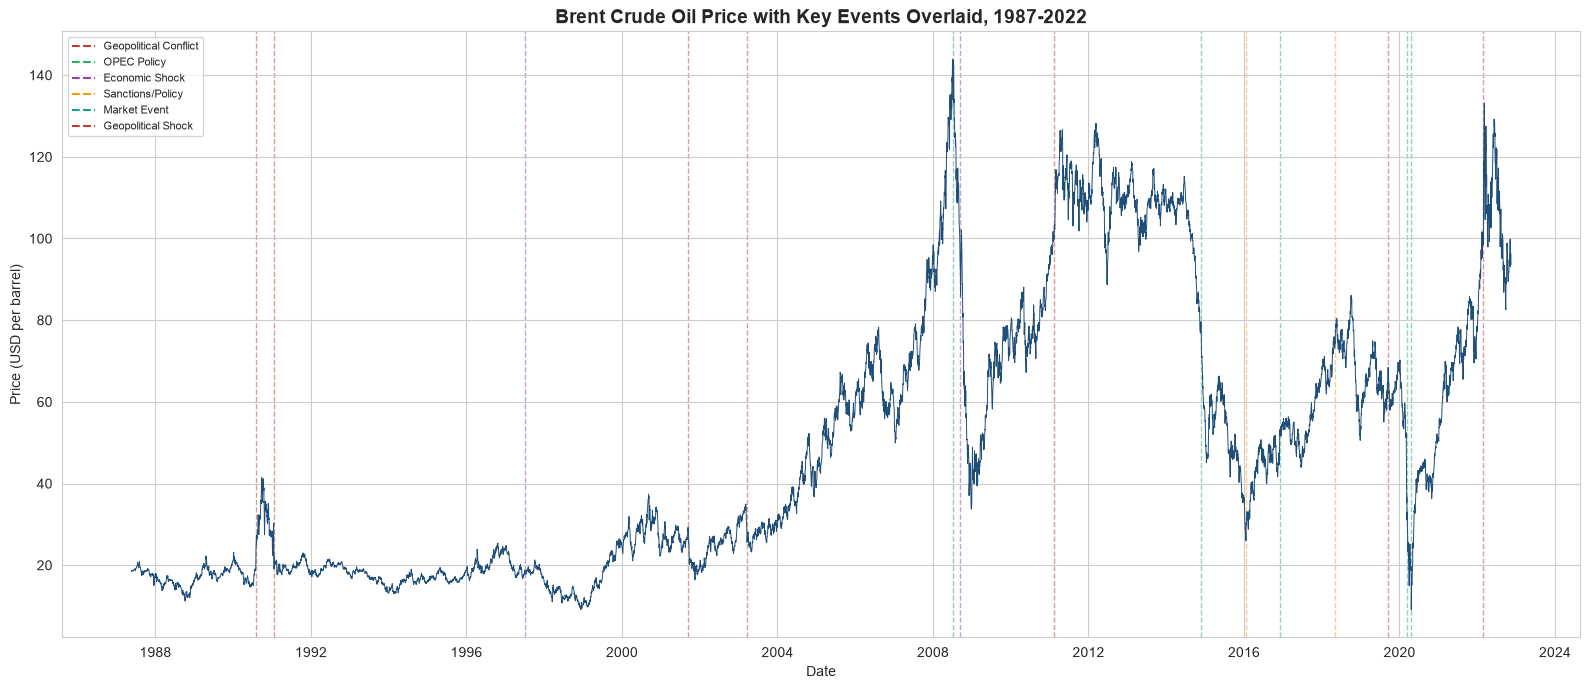

In [5]:
plot_events_overlay(df, events_df, save_path="../notebooks/plot_events_overlay.png")

### Observations: Raw Price Trend

The raw price series shows a clear long-term upward trend from 1987 to 2022, punctuated by sharp, discrete shocks rather than smooth gradual change. Major visible disruptions align with known events: the 1990–91 Gulf War spike, the 2008 peak above $147 followed by a financial-crisis collapse, the 2014–16 OPEC-driven price slide, and the extreme 2020 COVID-19 crash. This non-smooth, trending behavior is the first visual evidence that the raw price series is non-stationary, which we confirm statistically below.

### Observations: Log Returns and Volatility Clustering

Unlike the raw price series, log returns fluctuate around zero with no visible long-term trend, consistent with a stationary process. The plot shows clear **volatility clustering**: long calm periods interrupted by short bursts of extreme swings, most visibly around 2008–09 and 2020. This clustering — periods of high volatility followed by more high volatility, and calm followed by calm — is a hallmark of financial time series and motivates using log returns (not raw prices) as the primary series for change point modeling in Task 2.

### Observations: Stationarity Testing

The Augmented Dickey-Fuller test confirms the visual pattern: the raw price series has a p-value of 0.29, well above the 0.05 threshold, so we fail to reject the null hypothesis of a unit root — the raw series is **non-stationary**. Log returns produce a p-value of approximately 0.0000, strongly rejecting the unit root — log returns are **stationary**. This is the statistical justification for modeling log returns rather than raw prices in the Bayesian change point model.

### Observations: Volatility Patterns

The 30-day rolling volatility plot makes the clustering pattern from the log returns chart more explicit. Volatility is not constant over time — it spikes sharply during the 1990–91 Gulf War, the 2008 financial crisis, the 2014–16 OPEC price war, and reaches its highest level on record during the 2020 COVID-19 demand shock. This time-varying volatility suggests that a single global variance assumption would be too simplistic; it also supports the case for change point models that allow parameters to shift at specific dates rather than assuming constant behavior throughout.